# Just for Scratch Work

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

par = Path().cwd().parent
print(par)
sys.path.append(str(par))

from cfg_data import AnalysisBase
from metal import estimate_metal_threshold
from noise import (
    estimate_volume_slice_stats,
    leavein_median_noise_scale_penta,
    fit_mixture_distribution,
)

plt.style.use('dark_background')
cfg_file = Path.cwd().parent / "config.toml"

/Users/jim/Documents/GitHub/particles


## Load a volume

In [2]:
vol_data = AnalysisBase(cfg_path=cfg_file, vol_index=19, exp_index=0)
vol_data.grayscale_landmarks

{'air_grayvalue': 2,
 'core_grayvalue': np.int64(25),
 'metal_threshold': 170,
 'max_grayvalue': 248}

## Compute Slice Stats

In [3]:
if "slice_stats" not in locals():
    slice_stats = {}

slice_levels = np.arange(
    vol_data.vol_for_analysis.shape[0], step=vol_data.noise_slice_step
)
clip_scales = [1.5, 2.0, 2.5, 3.0]
clip_scale = 1.5  # vol_data.noise_clip_scale

for cs in clip_scales:
    if cs in slice_stats:
        continue
    noise_stats = estimate_volume_slice_stats(
        vol_data.vol_for_analysis,
        slice_levels,
        metal_threshold=vol_data.metal_threshold,
        min_area=vol_data.metal_min_area,
        grayscale_metal_margin=vol_data.metal_grayscale_margin,
        trunc_k=cs,
        use_parallel=True,
    )
    _stats = noise_stats["slice_stats"]
    sigma_corrected = [stats["sigma_corrected"] for stats in _stats.values()]
    sigma_diff = [stats["sigma_diff"] for stats in _stats.values()]
    rho1 = [stats["rho1"] for stats in _stats.values()]
    rho2 = [stats["rho2"] for stats in _stats.values()]
    stats_summary = {
        "sigma_corrected": np.array(sigma_corrected),
        "sigma_diff": np.array(sigma_diff),
        "rho1": np.array(rho1),
        "rho2": np.array(rho2),
    }
    slice_stats[cs] = stats_summary

### Inspect the slice stats

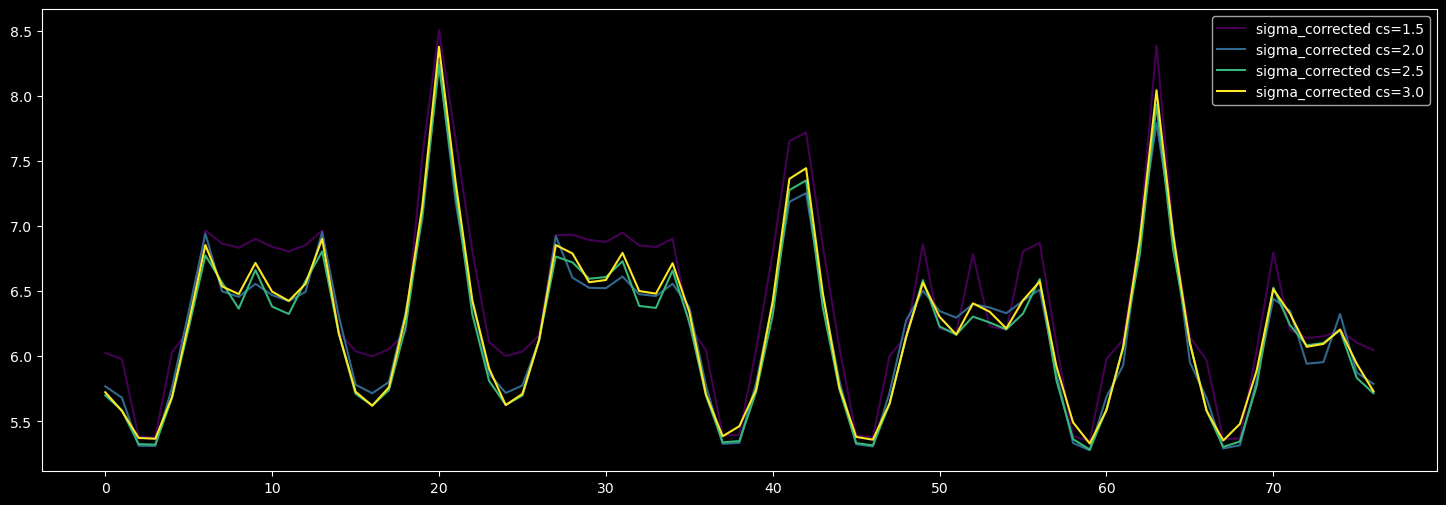

In [5]:
colors = plt.cm.viridis(np.linspace(0, 1, len(slice_stats)))
plt.figure(figsize=(18, 6))
for cs, stats_summary in slice_stats.items():
    plt.plot(stats_summary["sigma_corrected"], label=f"sigma_corrected cs={cs}", color=colors[0])
    colors = colors[1:]
    #plt.plot(stats_summary["sigma_diff"], label=f"sigma_diff cs={cs}")
    #plt.plot(stats_summary["rho1"], label=f"rho1 cs={cs}")
    #plt.plot(stats_summary["rho2"], label=f"rho2 cs={cs}")
plt.legend()
plt.show()

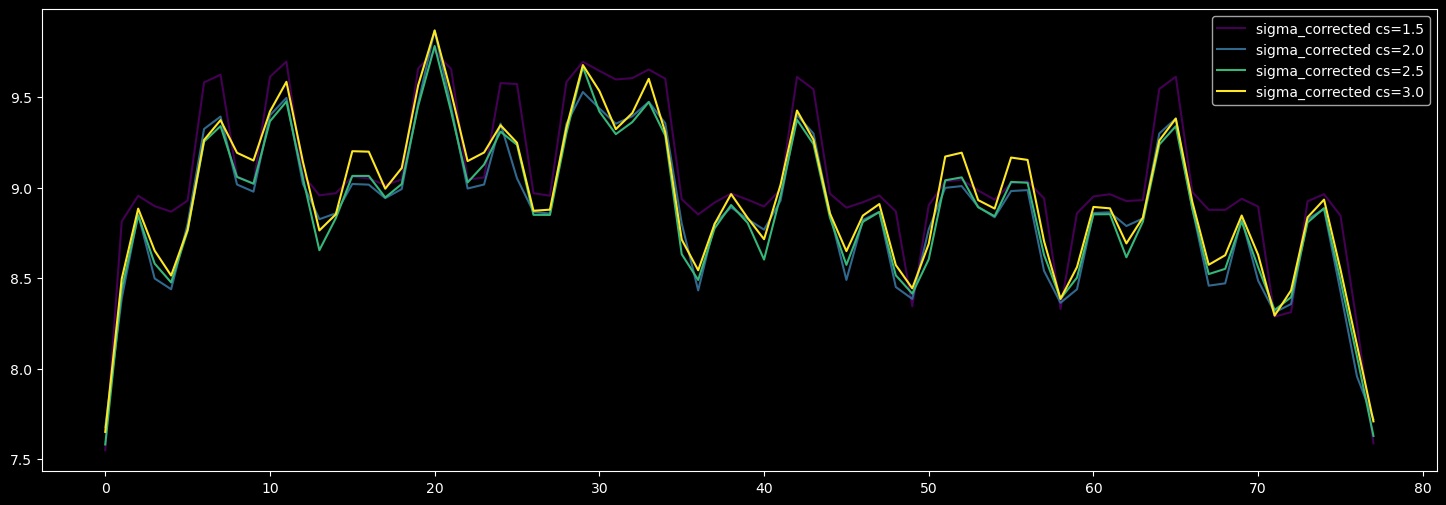

In [12]:
colors = plt.cm.viridis(np.linspace(0, 1, len(slice_stats)))
plt.figure(figsize=(18, 6))
for cs, stats_summary in slice_stats.items():
    plt.plot(stats_summary["sigma_corrected"], label=f"sigma_corrected cs={cs}", color=colors[0])
    colors = colors[1:]
    #plt.plot(stats_summary["sigma_diff"], label=f"sigma_diff cs={cs}")
    #plt.plot(stats_summary["rho1"], label=f"rho1 cs={cs}")
    #plt.plot(stats_summary["rho2"], label=f"rho2 cs={cs}")
plt.legend()
plt.show()

# Inspect the scan volume post-processing log

In [8]:
CSV_FILE_PATH = "/Users/jim/Documents/GitHub/particles/Data/volumes/process_raw_volume_log.csv"
import pandas as pd

df = pd.read_csv(CSV_FILE_PATH)
df.columns

Index(['input_file_name', 'output_file_name', 'input_file_path',
       'output_file_path', 'VOLUME_DIR', 'OUTPUT_NAME_SUFFIX',
       'OVERWRITE_OUTPUT', 'SKIP_NAME_SUFFIXES', 'VOXELS_X', 'VOXELS_Y',
       'VOXELS_Z', 'VOXELS_Z_UPPERLIMIT_UINT8', 'VOXELS_Z_UPPERLIMIT_UINT16',
       'VOXEL_SIZE_MM', 'CAN_DIAMETER_MM', 'CAN_HEIGHT_MM',
       'RUN_ADJUST_CONTRAST', 'RUN_ALIGN', 'RUN_CROP_RADIAL',
       'RUN_MASK_RADIAL', 'RUN_CROP_AXIAL', 'RUN_FLIP_Y',
       'MAX_INPUT_PERCENTILE', 'DOWNSAMPLING_FACTOR', 'SIGMA_ALIGNMENT',
       'MAX_ROTATION_ANGLE_DEGREES', 'ORDER_ALIGNMENT_ROTATION',
       'ALIGN_COMBINED', 'RADIAL_PADDING_MM', 'SIGMA_RADIAL_CROPPING',
       'RELATIVE_DETECTED_DIAMETER_TOLERANCE', 'AXIAL_PADDING_MM',
       'PEAK_OFFSET_MM', 'EDGE_DETECTION_SIGMA_VOXELS',
       'UPPER_CROP_DISTANCE_MM', 'ROTATION_CHUNK_BYTES', 'VERBOSE',
       'PROCESS_LOG_FILE', 'theta_degrees', 'phi_degrees',
       'theta_rotation_seconds', 'phi_rotation_seconds',
       'time_seconds_load

In [10]:
df_info = df[df.columns[38:]]
df_info.head()

,theta_degrees,phi_degrees,theta_rotation_seconds,phi_rotation_seconds,time_seconds_load_raw_volume,time_seconds_adjust_contrast,time_seconds_align,time_seconds_downcast_to_uint8,time_seconds_crop_radial,time_seconds_mask_radial,time_seconds_crop_axial,time_seconds_flip_y,time_seconds_save_raw_volume,time_seconds_total
0,-0.103330,0.255557,447.913425,472.788476,53.216422,8.708187,920.971813,0.000003,0.081576,1.355288,13.515952,0.960578,27.335612,1026.147513
1,-0.164629,0.268251,467.857381,472.652235,54.203245,9.476230,940.778412,0.000003,0.078998,1.031334,12.943479,0.777694,26.967487,1046.257647


In [ ]:
slice_stats = noise_stats["slice_stats"]
slice_idxs = slice_stats.keys()
slab_thickness = vol_data.slab_thickness
analysis_vol = vol_data.vol_for_analysis
slice_idxs = [
    s
    for s in slice_idxs
    if s >= slab_thickness // 2 and s < analysis_vol.shape[0] - slab_thickness // 2
]
residuals = {}
for s in slice_idxs:
    residuals[s] = analysis_vol[s].astype(np.int16) - np.median(
        analysis_vol[s - slab_thickness // 2 : s + slab_thickness // 2 + 1], axis=0
    ).astype(np.int16)

In [ ]:
residual_noise_estimates = {}
for k in [2.25, 2.5, 2.75, 3.0]:
    sigma_r = []
    for s in slice_idxs:
        w, mu, sigma = fit_mixture_distribution(residuals[s], clip_scale=k)
        sigma_r.append(sigma)
    residual_noise_estimates[k] = sigma_r

# Rotations using skimage

In [24]:
import numpy as np
from skimage.transform import warp
from scipy.ndimage import rotate
from time import perf_counter


def rotate_volume_warp(volume, angle_degrees, axes, order=1):
    angle = np.deg2rad(angle_degrees)
    c = np.cos(angle)
    s = np.sin(angle)

    matrix = np.eye(3)
    a, b = axes

    matrix[a, a] = c
    matrix[a, b] = s
    matrix[b, a] = -s
    matrix[b, b] = c

    center = (np.array(volume.shape) - 1) / 2
    offset = center - matrix @ center

    def inverse_map(*coords):
        coords_array = np.stack(coords, axis=-1)

        mapped = np.einsum(
            "...j,ij->...i",
            coords_array,
            matrix,
        )
        mapped += offset
        return mapped

    rotated = warp(
        volume,
        inverse_map=inverse_map,
        output_shape=volume.shape,
        order=order,
        mode="constant",
        cval=0,
        preserve_range=True,
    )

    return rotated.astype(volume.dtype, copy=False)

In [25]:
np.random.seed(0)
vol = (np.random.random((100, 100, 100)) * 255).astype(np.uint8)

theta = 0.2
phi = 0.1

start = perf_counter()
rot = rotate_volume_warp(vol, theta, axes=(1,2), order=3)
rot = rotate_volume_warp(rot, phi, axes=(0,2), order=3)
end = perf_counter()
print("Elapsed time for skimage:", end - start)

start = perf_counter()
rot = rotate(vol, theta, axes=(1,2), order=3, mode="constant", cval=0) #rotate_volume_warp(vol, theta, axes=(1,2))
rot = rotate(rot, phi, axes=(0,2), order=3, mode="constant", cval=0) #rotate_volume_warp(rot, phi, axes=(0,2))
end = perf_counter()
print("Elapsed time for scipy:", end - start)


Elapsed time for skimage: 0.4671114170050714
Elapsed time for scipy: 0.10148450000269804


# Inspect the histogram of Pavel's slice

In [ ]:
slice_file = Path("/Users/jim/Downloads/pavel_slice.png")
slice_img = cv2.imread(slice_file, cv2.IMREAD_GRAYSCALE)
plt.imshow(slice_img)
plt.show()
hist, bin_edges = np.histogram(slice_img.ravel(), bins=255)
print(len(bin_edges), len(hist))

hist[0] = 0
plt.plot(bin_edges[:-1], hist)
plt.show()


In [ ]:
def fit_circle(mask):
    from scipy.ndimage import binary_erosion

    mask = mask.astype(bool)

    # Extract the boundary of a filled mask
    boundary = mask & ~binary_erosion(mask)

    y, x = np.nonzero(boundary)

    if len(x) < 3:
        raise ValueError("At least three boundary points are required")

    x = x.astype(np.float64)
    y = y.astype(np.float64)

    # x² + y² = 2*cx*x + 2*cy*y + q
    A = np.column_stack((2 * x, 2 * y, np.ones_like(x)))
    b = x**2 + y**2

    cx, cy, q = np.linalg.lstsq(A, b, rcond=None)[0]
    radius = np.sqrt(q + cx**2 + cy**2)

    return cx, cy, radius


tmp = cv2.GaussianBlur(slice_img, (11, 11), 0)
scharr_x = cv2.Scharr(tmp, cv2.CV_32F, 1, 0)
scharr_y = cv2.Scharr(tmp, cv2.CV_32F, 0, 1)
scharr = np.sqrt(scharr_x**2 + scharr_y**2)
mask = scharr > 1300
mask = mask.astype(np.uint8) * 255
cy, cx, radius = fit_circle(mask)
plt.scatter(cx, cy, color="red", s=10)
mask_with_circle = mask.astype(np.uint8).copy()
cv2.circle(mask_with_circle, (int(cx), int(cy)), int(radius), color=255, thickness=3)
plt.imshow(mask_with_circle, cmap="gray")
plt.colorbar()
plt.show()

In [ ]:
def fit_quadratic_surface(image, threshold=150, max_points=None):
    if image.ndim != 2:
        raise ValueError("image must be a 2D array")

    height, width = image.shape
    mask = image < threshold

    y, x = np.nonzero(mask)
    z = image[mask].astype(np.float64)

    if len(z) < 6:
        raise ValueError("At least six selected pixels are required")

    # Optional subsampling for very large images
    if max_points is not None and len(z) > max_points:
        rng = np.random.default_rng(0)
        indices = rng.choice(len(z), max_points, replace=False)
        x, y, z = x[indices], y[indices], z[indices]

    # Normalize coordinates approximately to [-1, 1]
    xn = 2.0 * x / max(width - 1, 1) - 1.0
    yn = 2.0 * y / max(height - 1, 1) - 1.0

    design = np.column_stack(
        [
            xn**2,
            xn * yn,
            yn**2,
            xn,
            yn,
            np.ones_like(xn),
        ]
    )

    coefficients, *_ = np.linalg.lstsq(design, z, rcond=None)

    # Evaluate without constructing another large design matrix
    yy, xx = np.ogrid[:height, :width]
    xx = 2.0 * xx / max(width - 1, 1) - 1.0
    yy = 2.0 * yy / max(height - 1, 1) - 1.0

    a, b, c, d, e, f = coefficients
    surface = a * xx**2 + b * xx * yy + c * yy**2 + d * xx + e * yy + f

    return surface, coefficients

In [ ]:
tmp = slice_img.copy()
y, x = np.ogrid[: slice_img.shape[0], : slice_img.shape[1]]
outside = (x - cx) ** 2 + (y - cy) ** 2 > radius**2
tmp[outside] = 255
surface, coeffs = fit_quadratic_surface(slice_img, threshold=180, max_points=None)

plt.imshow(surface, cmap="viridis")
plt.colorbar()
plt.show()
print(surface.dtype)

In [ ]:
detrend_slice = slice_img.astype(np.float32) + surface.astype(np.float32)
detrend_slice -= detrend_slice.min()
detrend_slice = np.clip(detrend_slice, 0, 255)
print(detrend_slice.max())
plt.imshow(detrend_slice, cmap="viridis")
plt.colorbar()
plt.show()

circle_mask = np.zeros_like(slice_img, dtype=np.uint8)
y, x = np.ogrid[: slice_img.shape[0], : slice_img.shape[1]]
circle_mask[(x - cx) ** 2 + (y - cy) ** 2 <= radius**2] = 255
dhist, dbins = np.histogram((detrend_slice * circle_mask).ravel(), bins=255)
dhist[0] = 0
plt.plot(dbins[:-1], dhist)
plt.show()

In [ ]:
slice_file = Path("/Users/jim/Downloads/standard_slice.png")
slice_img = cv2.imread(slice_file, cv2.IMREAD_GRAYSCALE)
plt.imshow(slice_img)
plt.show()
hist, bin_edges = np.histogram(slice_img.ravel(), bins=255)
print(len(bin_edges), len(hist))

hist[0] = 0
plt.plot(bin_edges[:-1], hist)
plt.show()


In [ ]:
from scipy.stats import norm

T = np.array([3.0, 3.5, 4.0, 4.2, 4.5, 5.0])
area = norm.sf(T)
plt.plot(T, np.log(area))
# plt.yscale('log')
plt.show()

# Scratch

In [ ]:
import os
from pathlib import Path
import shutil

os.getcwd()


vol_dir = Path("/volumes/ssk ssd/raw")
vol_dir.exists()

_8bit_vol = vol_dir / "M50L-06.raw"
_32bit_vol = vol_dir / "M50L-06_4min.vol"

voxels_x, voxels_y = 1425, 1425
voxels_z = Path.stat(_8bit_vol).st_size / (voxels_x * voxels_y)

print(voxels_z)
# vol_8 = np.memmap(_8bit_vol, shape=(voxels_z, voxels_y, voxels_x))

In [ ]:
vol_dir = Path("../Data/volumes")
vol_dir.exists()
vol_file = "M50L-01_processed_flipped.raw"
vol_path = vol_dir / vol_file
voxels_x, voxels_y = 1340, 1340
voxels_z = vol_path.stat().st_size // (voxels_x * voxels_y)
vol = np.memmap(
    vol_path, dtype=np.uint8, mode="r", shape=(voxels_z, voxels_y, voxels_x)
)
middle_slice = vol[voxels_z // 2, :, :]

plt.imshow(middle_slice)

In [ ]:
volume_files = list(vol_dir.glob("*_flipped.raw"))
print(len(volume_files))
for vf in volume_files:
    stem = vf.stem
    idx = stem.find("_")
    idx = stem.find("_", idx + 1)
    new_stem = stem[:idx]
    new_name = new_stem + vf.suffix
    new_path = vf.with_name(new_name)
    vf.rename(new_path)
    # print(f"Old name {stem+vf.suffix}, New path: {new_path}")
    # break


In [ ]:
x = 21.5 / 800
x * x / 3